In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv('AQI Bangladesh.csv')

In [4]:
data.isnull().sum()

city_id                  0
city_name                0
lat                      0
lon                      0
datetime                 0
pm10                     0
pm2_5                    0
carbon_monoxide          0
carbon_dioxide      774327
nitrogen_dioxide         0
sulphur_dioxide          0
ozone                    0
aqi                    696
dtype: int64

In [5]:
features = ['lat', 'lon', 'pm10', 'pm2_5', 'carbon_monoxide', 
            'nitrogen_dioxide', 'sulphur_dioxide', 'ozone']
target = 'aqi'

In [6]:
data.head()

,city_id,city_name,lat,lon,datetime,pm10,pm2_5,carbon_monoxide,carbon_dioxide,nitrogen_dioxide,sulphur_dioxide,ozone,aqi
0,7701354,Azimpur,23.7298,90.3854,2022-08-05T00:00,25.0,16.7,252.0,NaN,18.6,5.2,13.0,50.0
1,7701354,Azimpur,23.7298,90.3854,2022-08-05T01:00,18.5,12.3,249.0,NaN,18.5,5.7,19.0,50.0
2,7701354,Azimpur,23.7298,90.3854,2022-08-05T02:00,16.1,10.9,244.0,NaN,18.4,6.5,27.0,51.0
3,7701354,Azimpur,23.7298,90.3854,2022-08-05T03:00,15.4,10.3,233.0,NaN,17.2,6.9,39.0,51.0
4,7701354,Azimpur,23.7298,90.3854,2022-08-05T04:00,16.8,11.3,217.0,NaN,14.8,6.2,51.0,51.0


In [7]:
data.shape

(1048551, 13)

In [21]:
new = data[features + [target]].dropna()

In [9]:
new.shape

(1047855, 9)

In [22]:
new.isnull().sum()

lat                 0
lon                 0
pm10                0
pm2_5               0
carbon_monoxide     0
nitrogen_dioxide    0
sulphur_dioxide     0
ozone               0
aqi                 0
dtype: int64

In [23]:
new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1047855 entries, 0 to 1048550
Data columns (total 9 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   lat               1047855 non-null  float64
 1   lon               1047855 non-null  float64
 2   pm10              1047855 non-null  float64
 3   pm2_5             1047855 non-null  float64
 4   carbon_monoxide   1047855 non-null  float64
 5   nitrogen_dioxide  1047855 non-null  float64
 6   sulphur_dioxide   1047855 non-null  float64
 7   ozone             1047855 non-null  float64
 8   aqi               1047855 non-null  float64
dtypes: float64(9)
memory usage: 79.9 MB


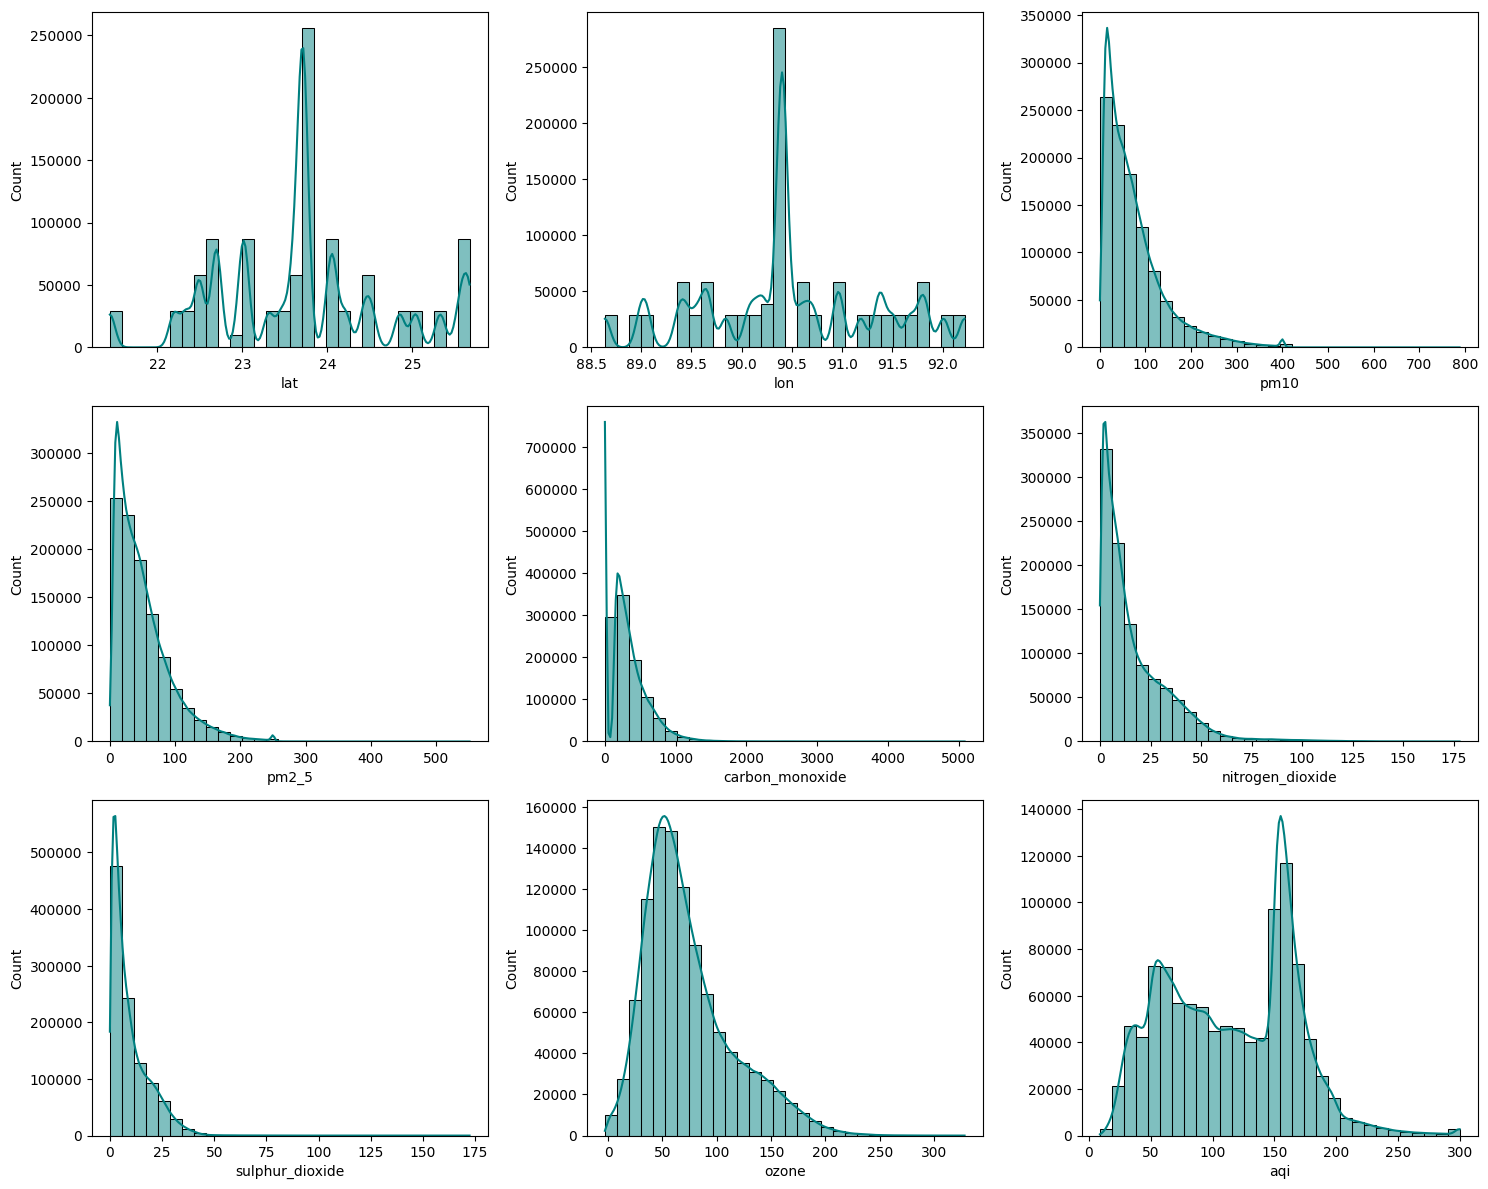

In [24]:
columns = features + [target]
plt.figure(figsize=(15, 12))

for i, col in enumerate(columns):
    plt.subplot(3, 3, i + 1)
    sns.histplot(new[col], kde=True, color='teal', bins=30)

plt.tight_layout()
plt.show()

In [25]:
skewed_cols = ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide']
for col in skewed_cols:
    new[col] = np.log1p(new[col])

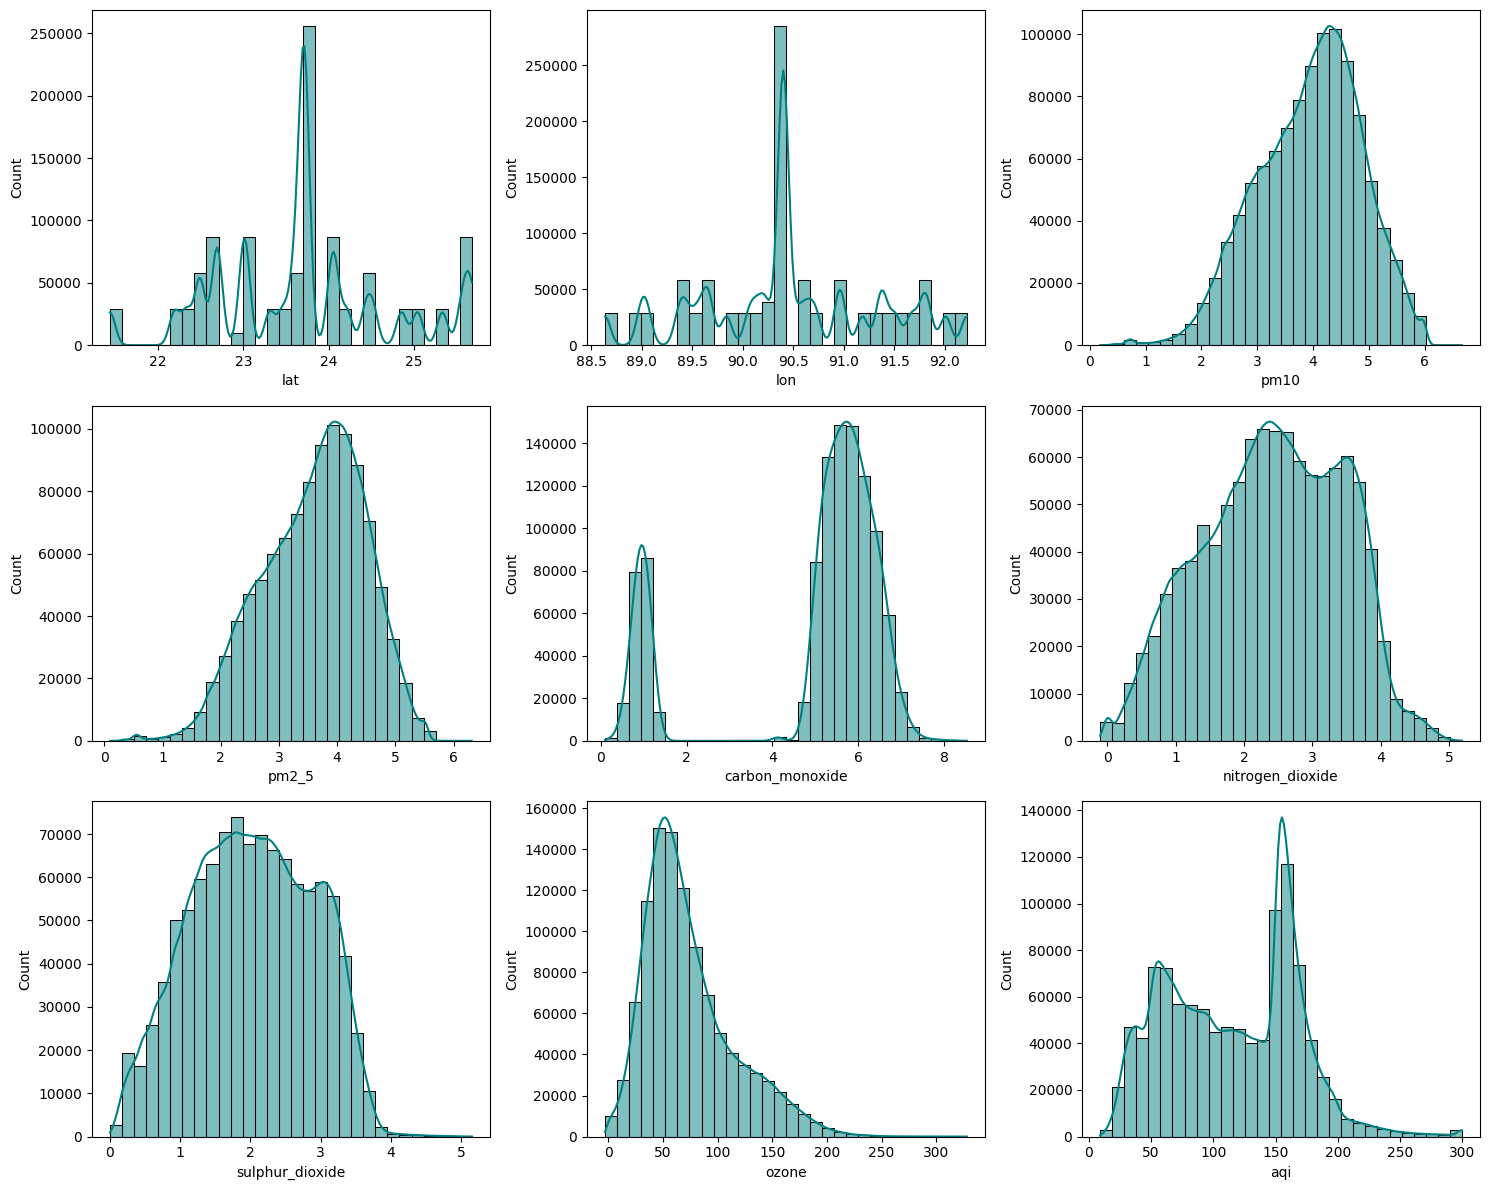

In [26]:
columns = features + [target]
plt.figure(figsize=(15, 12))

for i, col in enumerate(columns):
    plt.subplot(3, 3, i + 1)
    sns.histplot(new[col], kde=True, color='teal', bins=30)

plt.tight_layout()
plt.show()

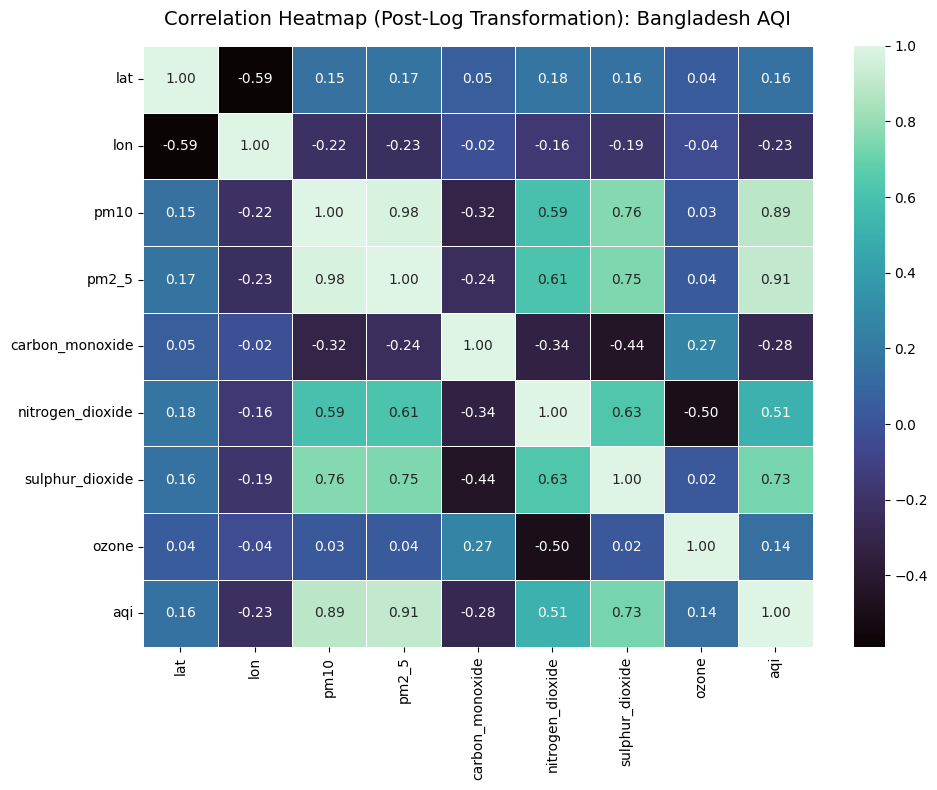

In [27]:
# Heatmap
corr = new[features + [target]].corr()
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr, 
    annot=True, 
    cmap='mako', 
    fmt=".2f", 
    linewidths=0.5,
)

plt.title('Correlation Heatmap (Post-Log Transformation): Bangladesh AQI', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = ['lat', 'lon', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone']
target_col = 'aqi'

X_raw_data = new[feature_cols].to_numpy()
y_raw_data = new[target_col].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X_raw_data, y_raw_data, 
    test_size=0.2, 
    random_state=42
)

if X_train.ndim == 1:
    X_train = X_train.reshape(-1, len(feature_cols))
if X_test.ndim == 1:
    X_test = X_test.reshape(-1, len(feature_cols))


In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [53]:
model = Sequential([
Dense(512, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.1),
    Dense(64, activation='relu'),
    Dense(1)
])

In [54]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
    loss='mse',       
    metrics=['mae'])

In [55]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 512)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177,153 (692.00 KB)

 Trainable params: 177,153 (692.00 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [57]:
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 524.8889 - mae: 15.5813 - val_loss: 267.4095 - val_mae: 11.7020
Epoch 2/50
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - loss: 313.8747 - mae: 13.1777 - val_loss: 256.3426 - val_mae: 11.3136
Epoch 3/50
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 82s 13ms/step - loss: 300.2722 - mae: 12.8201 - val_loss: 250.2993 - val_mae: 11.0385
Epoch 4/50
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 289.0293 - mae: 12.5067 - val_loss: 246.3659 - val_mae: 10.7835
Epoch 5/50
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - loss: 279.5156 - mae: 12.2358 - val_loss: 259.0204 - val_mae: 11.9124
Epoch 6/50
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 42s 13ms/step - loss: 270.5385 - mae: 11.9629 - val_loss: 276.6823 - val_mae: 12.7634
Epoch 7/50
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 42s 13ms/step - loss: 262.9363 - mae: 11.7089 - val_loss: 303.2151 - val_mae: 13.6877
Epoch 8/50
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 86s 14ms/step - loss: 257.6003 - mae: 11.5285 - val_loss: 334.

In [58]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

percentage_error = np.abs((y_test - y_pred) / y_test)
percentage_accuracy = np.mean(percentage_error <= 0.15) * 100

print(f"Mean Absolute Error (MAE):             {mae:.2f} AQI Points")
print(f"R-squared (R²) Score:                  {r2:.4f}")
print(f"Model Accuracy : {percentage_accuracy:.2f}%")

6550/6550 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step
Mean Absolute Error (MAE):             10.78 AQI Points
R-squared (R²) Score:                  0.9108
Model Accuracy : 70.37%


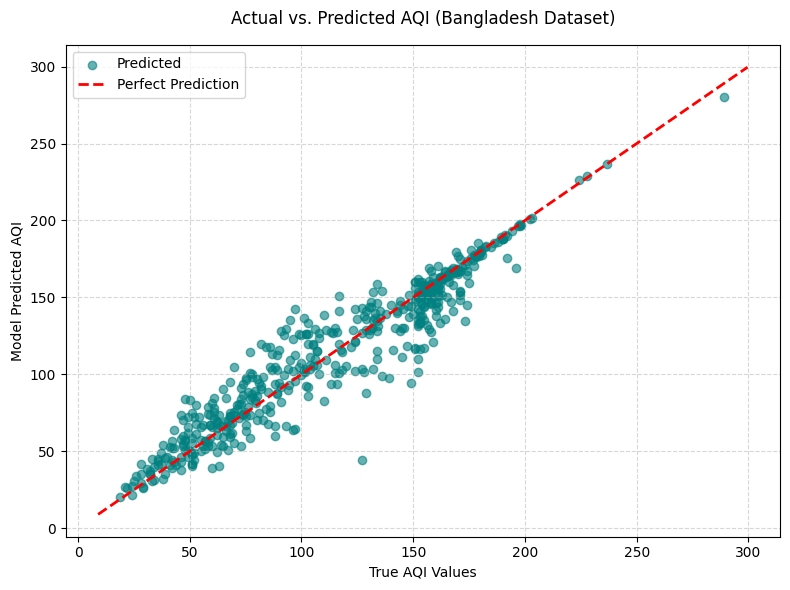

In [59]:
plt.figure(figsize=(8, 6))
# Plotting a subset of 500 points so the chart is clean and scannable
plt.scatter(y_test[:500], y_pred[:500], alpha=0.6, color='teal', label='Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Actual vs. Predicted AQI (Bangladesh Dataset)', fontsize=12, pad=15)
plt.xlabel('True AQI Values', fontsize=10)
plt.ylabel('Model Predicted AQI', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

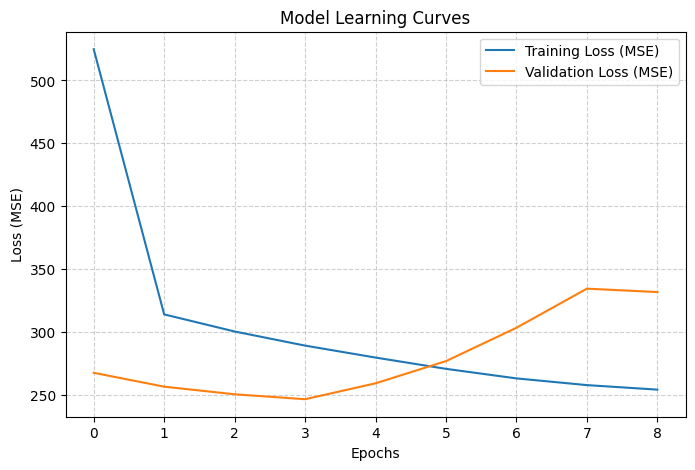

In [62]:
import matplotlib.pyplot as plt

# Plot Training vs Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Model Learning Curves', fontsize=12)
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)') # Changed from MAE to MSE
plt.legend(['Training Loss (MSE)', 'Validation Loss (MSE)'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [63]:
import joblib

model.save('bangladesh_aqi_ann_model.keras')

joblib.dump(scaler, 'aqi_scaler.joblib')
print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!
